In [1]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import r2_score, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# ── Paths ───────────────────────────────────────────────────
RESULTS_DIR = "../results/metrics"
MODELS_DIR  = "../models"
FIGS_DIR    = "../results/figures"
os.makedirs(FIGS_DIR, exist_ok=True)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# ── Load artifacts ──────────────────────────────────────────
with open(f"{RESULTS_DIR}/scaler_X.pkl", 'rb') as f: scaler_X = pickle.load(f)
with open(f"{RESULTS_DIR}/scaler_y.pkl", 'rb') as f: scaler_y = pickle.load(f)

df_all = pd.read_parquet(f"{RESULTS_DIR}/lab_cycles_labeled.parquet")

WINDOW       = 20
STRIDE       = 10
FEATURE_COLS = ['cap_Ah','v_mean','v_min','v_slope','i_mean',
                't_mean','t_max','energy_Wh','duration_min',
                'soc_start','soc_end','EFC_norm']
N_FEATURES   = len(FEATURE_COLS)

print(f"✅ Loaded  |  {len(df_all):,} cycles  |  {df_all['cell_id'].nunique()} cells")
print(f"   Splits: { {s: df_all[df_all['split']==s]['cell_id'].nunique() for s in ['train','val','test']} }")


✅ Loaded  |  213,995 cycles  |  206 cells
   Splits: {'train': 154, 'val': 26, 'test': 26}


In [2]:
class PILSTM(nn.Module):
    def __init__(self, input_size=12, hidden_size=64,
                 num_layers=2, dropout=0.4, fc_dims=[32,16]):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            dropout=dropout if num_layers>1 else 0.0,
                            batch_first=True)
        layers, in_dim = [], hidden_size
        for out_dim in fc_dims:
            layers += [nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = out_dim
        layers += [nn.Linear(in_dim, 1)]
        self.fc = nn.Sequential(*layers)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

model = PILSTM().to(device)
model.load_state_dict(torch.load(f"{MODELS_DIR}/best_pilstm.pt", map_location=device))
model.eval()
print(f"✅ Model loaded  |  Params: {sum(p.numel() for p in model.parameters()):,}")

def predict_cell(df_cell):
    """Run inference on a single cell, return EFC / true_RUL / pred_RUL arrays."""
    grp = df_cell.sort_values('EFC').reset_index(drop=True)
    X   = scaler_X.transform(grp[FEATURE_COLS].values)
    y   = scaler_y.transform(grp[['RUL']].values).flatten()

    efcs, trues, preds = [], [], []
    for i in range(WINDOW, len(grp)):
        x_seq = torch.tensor(X[i-WINDOW:i], dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            p = model(x_seq).item()
        efcs.append(grp['EFC'].iloc[i])
        trues.append(grp['RUL'].iloc[i])
        preds.append(np.clip(scaler_y.inverse_transform([[p]])[0][0], 0, 1))

    true_inv = np.array(trues)
    return np.array(efcs), true_inv, np.array(preds)


✅ Model loaded  |  Params: 55,873


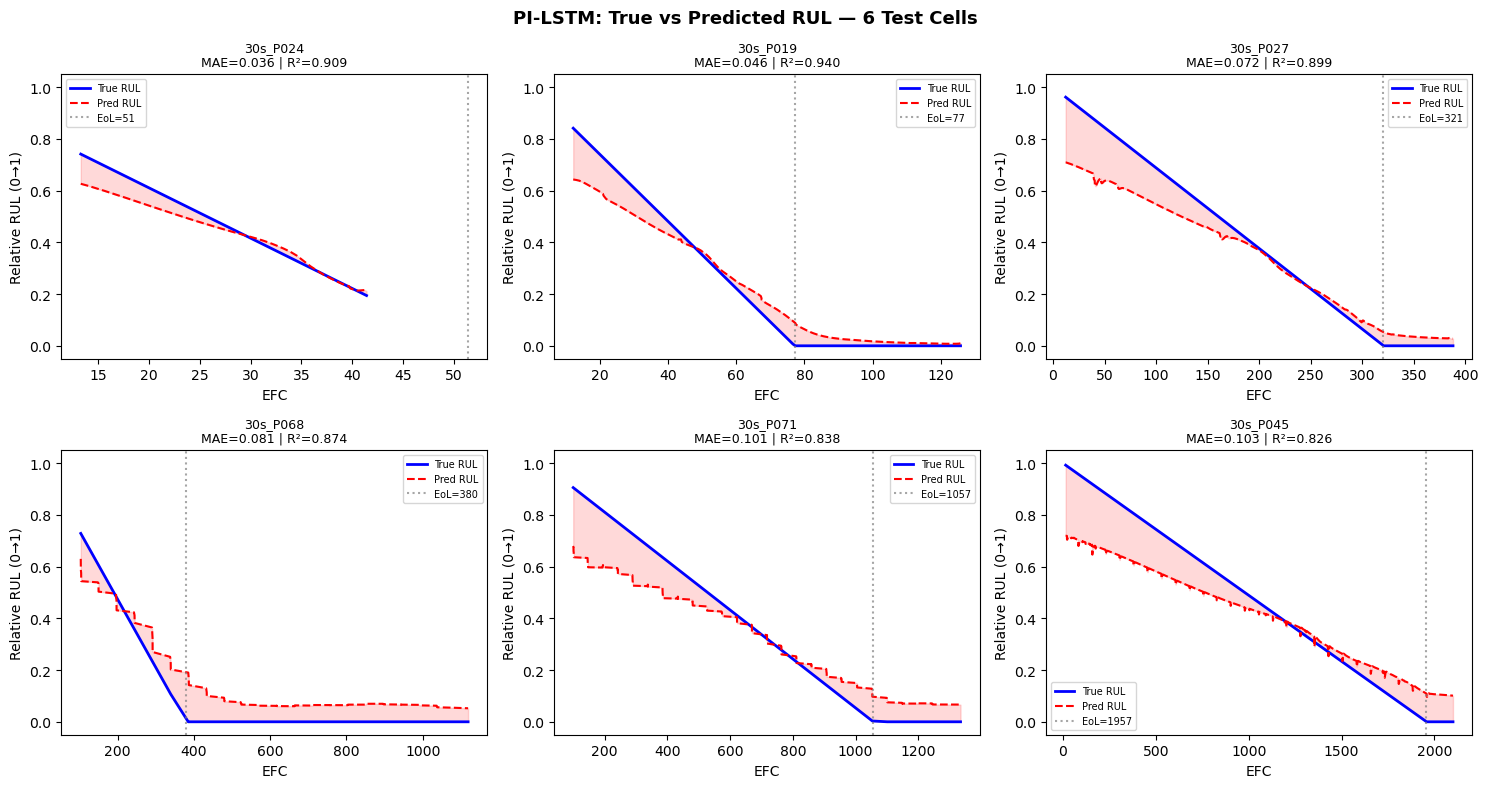

💾 Saved → results/figures/per_cell_rul_curves.png


In [3]:
test_cells = df_all[df_all['split']=='test']['cell_id'].unique()

# Pick 6 diverse cells — 2 short-lived, 2 medium, 2 long-lived
cell_eol   = df_all.groupby('cell_id')['EoL_EFC'].first()
test_eols  = cell_eol[test_cells].sort_values()
picks      = list(test_eols.index[[0, 2,                      # short
                                    len(test_eols)//2 - 1,
                                    len(test_eols)//2,        # medium
                                    -3, -1]])                  # long

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, cid in zip(axes, picks):
    efc, true_rul, pred_rul = predict_cell(df_all[df_all['cell_id']==cid])
    eol = cell_eol[cid]
    mae = mean_absolute_error(true_rul, pred_rul)
    r2  = r2_score(true_rul, pred_rul)

    ax.plot(efc, true_rul, 'b-',  linewidth=2,   label='True RUL')
    ax.plot(efc, pred_rul, 'r--', linewidth=1.5, label='Pred RUL')
    ax.fill_between(efc, true_rul, pred_rul, alpha=0.15, color='red')
    ax.axvline(eol, color='gray', linestyle=':', alpha=0.7, label=f'EoL={eol:.0f}')
    ax.set_title(f"{cid.split('_')[3]}_{cid.split('_')[4]}\n"
                 f"MAE={mae:.3f} | R²={r2:.3f}", fontsize=9)
    ax.set_xlabel('EFC'); ax.set_ylabel('Relative RUL (0→1)')
    ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.05)

plt.suptitle('PI-LSTM: True vs Predicted RUL — 6 Test Cells', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/per_cell_rul_curves.png", dpi=150)
plt.show()
print("💾 Saved → results/figures/per_cell_rul_curves.png")


Total test predictions: 23,153


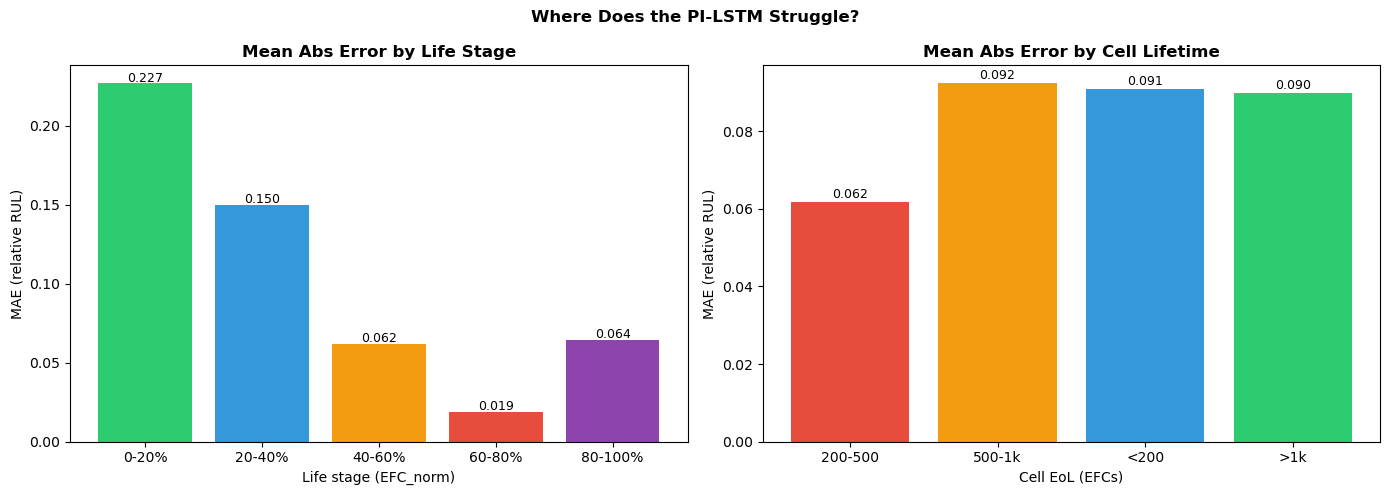

💾 Saved → results/figures/error_heatmap.png


In [4]:
# Run inference on ALL test cells
test_results = []
for cid in test_cells:
    efc, true_rul, pred_rul = predict_cell(df_all[df_all['cell_id']==cid])
    eol = cell_eol[cid]
    for e, t, p in zip(efc, true_rul, pred_rul):
        test_results.append({
            'cell_id':   cid,
            'EFC':       e,
            'EoL_EFC':   eol,
            'true_RUL':  t,
            'pred_RUL':  p,
            'abs_err':   abs(t - p),
            'EFC_norm':  e / eol,                    # life stage 0→1
            'eol_bucket': pd.cut([eol], bins=[0,200,500,1000,5000],
                                  labels=['<200','200-500','500-1k','>1k'])[0]
        })

res_df = pd.DataFrame(test_results)
print(f"Total test predictions: {len(res_df):,}")

# ── Error by life stage (binned EFC_norm) ───────────────────
res_df['life_bin'] = pd.cut(res_df['EFC_norm'],
                             bins=[0,.2,.4,.6,.8,1.0],
                             labels=['0-20%','20-40%','40-60%','60-80%','80-100%'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean abs error by life stage
err_by_life = res_df.groupby('life_bin', observed=True)['abs_err'].mean()
axes[0].bar(err_by_life.index, err_by_life.values,
            color=['#2ecc71','#3498db','#f39c12','#e74c3c','#8e44ad'])
axes[0].set_title('Mean Abs Error by Life Stage', fontweight='bold')
axes[0].set_xlabel('Life stage (EFC_norm)'); axes[0].set_ylabel('MAE (relative RUL)')
for i, v in enumerate(err_by_life.values):
    axes[0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

# Right: error by degradation speed (EoL bucket)
err_by_eol = res_df.groupby('eol_bucket', observed=True)['abs_err'].mean()
axes[1].bar(err_by_eol.index, err_by_eol.values,
            color=['#e74c3c','#f39c12','#3498db','#2ecc71'])
axes[1].set_title('Mean Abs Error by Cell Lifetime', fontweight='bold')
axes[1].set_xlabel('Cell EoL (EFCs)'); axes[1].set_ylabel('MAE (relative RUL)')
for i, v in enumerate(err_by_eol.values):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Where Does the PI-LSTM Struggle?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/error_heatmap.png", dpi=150)
plt.show()
print("💾 Saved → results/figures/error_heatmap.png")


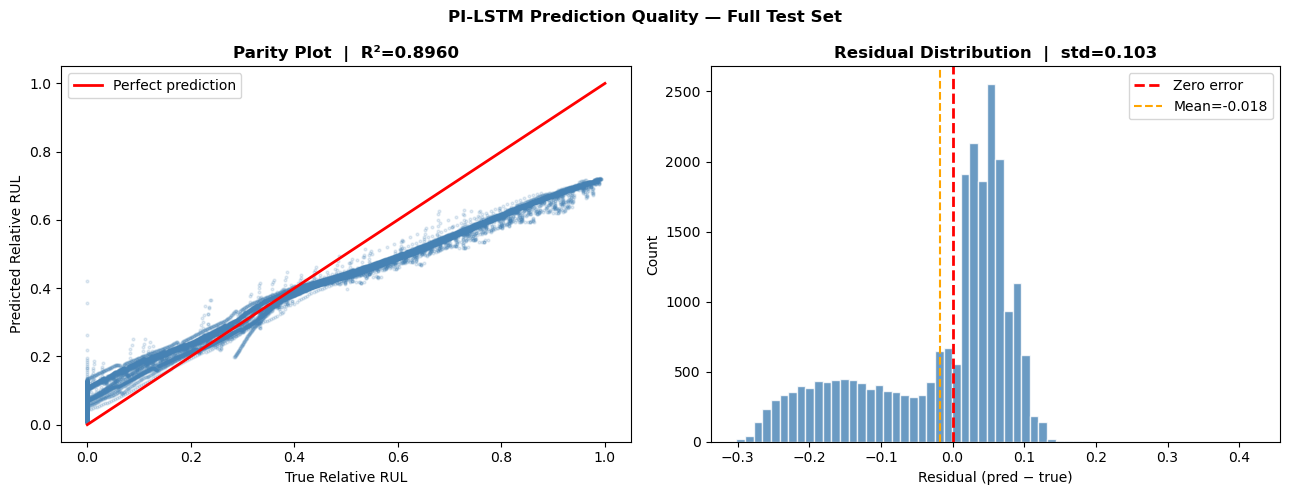

💾 Saved → results/figures/parity_residuals.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Parity plot (true vs pred) ───────────────────────
axes[0].scatter(res_df['true_RUL'], res_df['pred_RUL'],
                alpha=0.15, s=4, color='steelblue')
axes[0].plot([0,1],[0,1], 'r-', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('True Relative RUL')
axes[0].set_ylabel('Predicted Relative RUL')
axes[0].set_title(f'Parity Plot  |  R²={r2_score(res_df["true_RUL"], res_df["pred_RUL"]):.4f}',
                  fontweight='bold')
axes[0].legend(); axes[0].set_xlim(-0.05, 1.05); axes[0].set_ylim(-0.05, 1.05)

# ── Right: Residual distribution ───────────────────────────
residuals = res_df['pred_RUL'] - res_df['true_RUL']
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0,   color='red',    linestyle='--', linewidth=2, label='Zero error')
axes[1].axvline(residuals.mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean={residuals.mean():.3f}')
axes[1].set_xlabel('Residual (pred − true)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution  |  std={residuals.std():.3f}', fontweight='bold')
axes[1].legend()

plt.suptitle('PI-LSTM Prediction Quality — Full Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/parity_residuals.png", dpi=150)
plt.show()
print("💾 Saved → results/figures/parity_residuals.png")


In [6]:
# Full test metrics by EoL bucket
summary = res_df.groupby('eol_bucket', observed=True).apply(lambda g: pd.Series({
    'n_cells':   g['cell_id'].nunique(),
    'n_samples': len(g),
    'MAE':       mean_absolute_error(g['true_RUL'], g['pred_RUL']),
    'R²':        r2_score(g['true_RUL'], g['pred_RUL'])
})).round(4)

overall_mae = mean_absolute_error(res_df['true_RUL'], res_df['pred_RUL'])
overall_r2  = r2_score(res_df['true_RUL'], res_df['pred_RUL'])

print("=" * 55)
print("PI-LSTM TEST PERFORMANCE BY CELL LIFETIME")
print("=" * 55)
print(summary.to_string())
print("-" * 55)
print(f"OVERALL   MAE={overall_mae:.4f} ({overall_mae*100:.1f}%life)  R²={overall_r2:.4f}")
print("=" * 55)

summary.to_csv(f"{RESULTS_DIR}/nb04_error_summary.csv")
res_df.to_csv(f"{RESULTS_DIR}/nb04_test_results_full.csv", index=False)
print(f"\n💾 Saved → results/metrics/nb04_error_summary.csv")
print(f"💾 Saved → results/metrics/nb04_test_results_full.csv")
print(f"\n🚀 Notebook 04 complete — ready for NB05 EV transfer learning!")


PI-LSTM TEST PERFORMANCE BY CELL LIFETIME
            n_cells  n_samples     MAE      R²
eol_bucket                                    
200-500         9.0     7876.0  0.0618  0.9126
500-1k          5.0     7185.0  0.0924  0.8791
<200            9.0     1647.0  0.0910  0.8677
>1k             3.0     6445.0  0.0900  0.8773
-------------------------------------------------------
OVERALL   MAE=0.0812 (8.1%life)  R²=0.8960

💾 Saved → results/metrics/nb04_error_summary.csv
💾 Saved → results/metrics/nb04_test_results_full.csv

🚀 Notebook 04 complete — ready for NB05 EV transfer learning!
